## Step:0 Load and datset overview

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from scipy import stats
from ta.momentum import (RSIIndicator, StochasticOscillator,ROCIndicator, WilliamsRIndicator)
from ta.trend   import (MACD, CCIIndicator, SMAIndicator,EMAIndicator, ADXIndicator)
from ta.volatility import BollingerBands, AverageTrueRange
from ta.volume     import OnBalanceVolumeIndicator

# Resetting the dataframe path to the original file for future use
new_path = "..\\data\\filter_OHLCV.parquet"
df = pd.read_parquet(new_path)
df.columns = df.columns.str.lower()
df

,symbol,date,open,high,low,close,volume
0,BRK-B,2016-01-08,130.110001,130.399994,128.210007,128.330002,6101600
1,BRK-B,2016-01-13,128.970001,129.380005,125.709999,126.250000,6042400
2,BRK-B,2016-01-15,125.339996,126.809998,124.510002,126.139999,8145100
3,BRK-B,2016-01-29,126.660004,129.770004,126.110001,129.770004,6523800
4,BRK-B,2016-02-03,126.339996,126.629997,123.550003,126.239998,6607500
...,...,...,...,...,...,...,...
1220273,VICI,2020-07-02,15.681162,15.740225,15.260340,15.400615,4136400
1220274,VICI,2020-07-06,15.799288,15.865734,14.902272,14.928112,4423500
1220275,VICI,2020-07-07,14.691864,15.105303,14.573738,14.758309,2779800
1220276,VICI,2020-07-08,14.809990,14.950265,14.621728,14.913351,2158800


In [ ]:
# Basic info about the dataset
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nDtypes:\n", df.dtypes)
print("\nDate range:", df['date'].min(), "→", df['date'].max())
print("Unique stocks:", df['symbol'].nunique())
print("Total trading days per stock (avg):", round(df.groupby('symbol').size().mean(), 1))

Shape: (1220278, 7)

Columns: ['symbol', 'date', 'open', 'high', 'low', 'close', 'volume']

Dtypes:
 symbol               str
date      datetime64[ms]
open             float64
high             float64
low              float64
close            float64
volume             int64
dtype: object

Date range: 2016-01-04 00:00:00 → 2025-12-31 00:00:00
Unique stocks: 500
Total trading days per stock (avg): 2440.6


## Step:1 Feature Analysis(Base Research Paper)

In [ ]:
# group by ticker and date in ascending order
df = df.sort_values(["symbol", "date"], ascending=[True, True]).reset_index(drop=True)
print(f"Sorted: {df.shape[0]:,} rows | {df['symbol'].nunique()} tickers")

✅ Sorted: 1,220,278 rows | 500 tickers


In [ ]:
# Single function to compute all features for a given stock group
def add_all_features(grp: pd.DataFrame) -> pd.DataFrame:
    grp = grp.copy()

    # 1. Price-based features
    grp["Daily_Return"]  = grp["close"].pct_change()
    grp["Overnight_Gap"] = (grp["open"] - grp["close"].shift(1)) / grp["close"].shift(1)
    grp["HL_Range"]      = (grp["high"] - grp["low"]) / grp["close"]
    grp["CO_Spread"]     = (grp["close"] - grp["open"]) / grp["open"]
    grp["Upper_Shadow"]  = (grp["high"] - grp[["open","close"]].max(axis=1)) / grp["close"]
    grp["Lower_Shadow"]  = (grp[["open","close"]].min(axis=1) - grp["low"])  / grp["close"]
    grp["Body_Size"]     = (grp["close"] - grp["open"]).abs() / grp["close"]

    # 2. Moving Averages & Trend
    for w in [5, 10, 20, 50]:
        grp[f"SMA_{w}"] = SMAIndicator(grp["close"], window=w).sma_indicator()

    grp["EMA_12"]        = EMAIndicator(grp["close"], window=12).ema_indicator()
    grp["EMA_26"]        = EMAIndicator(grp["close"], window=26).ema_indicator()
    grp["Price_vs_SMA20"]= grp["close"] / grp["SMA_20"]
    grp["SMA5_vs_SMA20"] = grp["SMA_5"] / grp["SMA_20"]
    grp["EMA_Cross"]     = grp["EMA_12"] - grp["EMA_26"]

    # 3. Momentum & Oscillators
    grp["RSI_14"]     = RSIIndicator(grp["close"], window=14).rsi()

    macd_obj = MACD(grp["close"])
    grp["MACD"]       = macd_obj.macd()
    grp["MACD_Signal"]= macd_obj.macd_signal()
    grp["MACD_Hist"]  = macd_obj.macd_diff()

    stoch = StochasticOscillator(grp["high"], grp["low"], grp["close"])
    grp["Stoch_K"]    = stoch.stoch()
    grp["Stoch_D"]    = stoch.stoch_signal()

    grp["ROC_5"]      = ROCIndicator(grp["close"], window=5).roc()
    grp["ROC_10"]     = ROCIndicator(grp["close"], window=10).roc()
    grp["Williams_R"] = WilliamsRIndicator(grp["high"], grp["low"], grp["close"]).williams_r()
    grp["CCI_20"]     = CCIIndicator(grp["high"], grp["low"], grp["close"], window=20).cci()
    grp["ADX_14"]     = ADXIndicator(grp["high"], grp["low"], grp["close"], window=14).adx()

    # 4. Volatility & Price Action
    grp["ATR_14"]     = AverageTrueRange(grp["high"], grp["low"], grp["close"], window=14).average_true_range()

    bb = BollingerBands(grp["close"], window=20, window_dev=2)
    grp["BB_Upper"]    = bb.bollinger_hband()
    grp["BB_Lower"]    = bb.bollinger_lband()
    grp["BB_Mid"]      = bb.bollinger_mavg()
    grp["BB_Width"]    = (grp["BB_Upper"] - grp["BB_Lower"]) / grp["BB_Mid"]
    grp["BB_Position"] = (grp["close"] - grp["BB_Lower"]) / (grp["BB_Upper"] - grp["BB_Lower"] + 1e-9)

    grp["Rolling_Std_5"]   = grp["Daily_Return"].rolling(5).std()
    grp["Rolling_Std_20"]  = grp["Daily_Return"].rolling(20).std()
    grp["Volatility_Ratio"]= grp["Rolling_Std_5"] / (grp["Rolling_Std_20"] + 1e-9)

    # 5. Volume-based features
    vol_ma = grp["volume"].rolling(20).mean()

    grp["Volume_MA_Ratio"]    = grp["volume"] / (vol_ma + 1e-9)
    grp["OBV"]                = OnBalanceVolumeIndicator(grp["close"], grp["volume"]).on_balance_volume()
    grp["OBV_Signal"]         = grp["OBV"].ewm(span=9).mean()
    grp["Volume_Spike"]       = (grp["volume"] > 2 * vol_ma).astype(int)
    grp["VWAP"]               = (grp["close"] * grp["volume"]).rolling(20).sum() / grp["volume"].rolling(20).sum()
    grp["Price_vs_VWAP"]      = grp["close"] / (grp["VWAP"] + 1e-9)
    grp["Volume_Return_Corr"] = grp["Daily_Return"].rolling(10).corr(grp["volume"].pct_change())

    # 6. Lagged features
    for lag in [1, 2, 3]:
        grp[f"Return_Lag{lag}"] = grp["Daily_Return"].shift(lag)

    grp["Volume_Lag1"] = grp["Volume_MA_Ratio"].shift(1)
    grp["High_Lag1"]   = grp["high"].shift(1)
    grp["Low_Lag1"]    = grp["low"].shift(1)

    # Consecutive up days - safe inside per-stock group
    up = grp["Daily_Return"].gt(0)
    grp["Consecutive_Up"] = (
        up.groupby((up != up.shift()).cumsum()).cumcount() + 1
    ) * up

    grp["Day_of_Week"]  = grp["date"].dt.dayofweek
    grp["Month"]        = grp["date"].dt.month
    grp["Is_Month_End"] = grp["date"].dt.is_month_end.astype(int)

    return grp

# Apply feature engineering per stock group
required_cols = {"symbol", "date", "open", "high", "low", "close", "volume"}
if not required_cols.issubset(df.columns):
    df = pd.read_parquet(new_path)
    df.columns = df.columns.str.lower()
print("Computing features per ticker - this takes ~1-2 min for 500 stocks...")

feature_frames = []
for symbol, grp in df.groupby("symbol", sort=False):
    grp = grp.copy()
    grp["symbol"] = symbol
    feature_frames.append(add_all_features(grp))
df = pd.concat(feature_frames, ignore_index=True)
df = df.sort_values(["symbol", "date"]).reset_index(drop=True)
print(f"Features added: {df.shape[0]:,} rows x {df.shape[1]} columns")
df


Computing features per ticker - this takes ~1-2 min for 500 stocks...
Features added: 1,220,278 rows x 60 columns


,symbol,date,open,high,low,close,volume,Daily_Return,Overnight_Gap,HL_Range,...,Return_Lag1,Return_Lag2,Return_Lag3,Volume_Lag1,High_Lag1,Low_Lag1,Consecutive_Up,Day_of_Week,Month,Is_Month_End
0,A,2016-01-04,37.824543,37.944297,37.161277,37.483696,3287300,NaN,NaN,0.020890,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,0
1,A,2016-01-05,37.520545,37.723211,37.161277,37.354729,2587200,-0.003441,0.000983,0.015043,...,NaN,NaN,NaN,NaN,37.944297,37.161277,0,1,1,0
2,A,2016-01-06,37.069159,37.760060,36.894129,37.520546,2103600,0.004439,-0.007645,0.023079,...,-0.003441,NaN,NaN,NaN,37.723211,37.161277,1,2,1,0
3,A,2016-01-07,36.977030,36.986244,35.751834,35.926861,3504300,-0.042475,-0.014486,0.034359,...,0.004439,-0.003441,NaN,NaN,37.760060,36.894129,0,3,1,0
4,A,2016-01-08,36.129522,36.580908,35.438621,35.549164,3736700,-0.010513,0.005641,0.032133,...,-0.042475,0.004439,-0.003441,NaN,36.986244,35.751834,0,4,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1220273,ZTS,2025-12-24,122.045745,124.613567,122.006086,124.415276,2369000,0.015784,-0.003562,0.020958,...,-0.001939,0.012598,-0.004236,0.780559,122.918214,121.411227,1,2,12,0
1220274,ZTS,2025-12-26,124.088098,125.238159,123.731180,125.148933,3226800,0.005897,-0.002630,0.012041,...,0.015784,-0.001939,0.012598,0.384482,124.613567,122.006086,2,4,12,0
1220275,ZTS,2025-12-29,125.079544,125.763629,124.484676,124.901085,4465600,-0.001980,-0.000554,0.010240,...,0.005897,0.015784,-0.001939,0.523582,125.238159,123.731180,0,0,12,0
1220276,ZTS,2025-12-30,124.474765,126.507204,124.375615,125.327400,3230200,0.003413,-0.003413,0.017008,...,-0.001980,0.005897,0.015784,0.711189,125.763629,124.484676,1,1,12,0


In [12]:
df.isnull().sum()

symbol                    0
date                      0
open                      0
high                      0
low                       0
close                     0
volume                    0
Daily_Return            500
Overnight_Gap           500
HL_Range                  0
CO_Spread                 0
Upper_Shadow              0
Lower_Shadow              0
Body_Size                 0
SMA_5                  2000
SMA_10                 4500
SMA_20                 9500
SMA_50                24497
EMA_12                 5500
EMA_26                12500
Price_vs_SMA20         9500
SMA5_vs_SMA20          9500
EMA_Cross             12500
RSI_14                 6500
MACD                  12500
MACD_Signal           16500
MACD_Hist             16500
Stoch_K                6731
Stoch_D                7781
ROC_5                  2500
ROC_10                 5000
Williams_R             6731
CCI_20                 9629
ADX_14                    0
ATR_14                    0
BB_Upper            

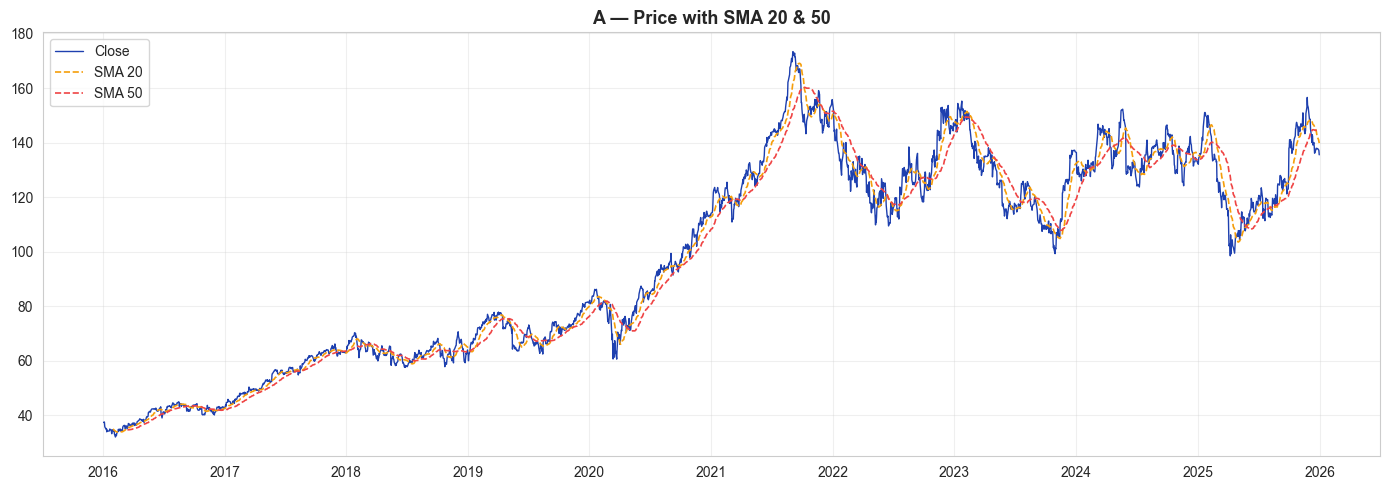

In [ ]:
# Pick one stock for visualization
SAMPLE_TICKER = df["symbol"].iloc[0]
s = df[df["symbol"] == SAMPLE_TICKER].copy()

# Moving Averages
plt.figure(figsize=(14, 5))
plt.plot(s["date"], s["close"],   label="Close",  linewidth=1,   color="#1e40af")
plt.plot(s["date"], s["SMA_20"],  label="SMA 20", linewidth=1.2, color="#f59e0b", linestyle="--")
plt.plot(s["date"], s["SMA_50"],  label="SMA 50", linewidth=1.2, color="#ef4444", linestyle="--")
plt.title(f"{SAMPLE_TICKER} - Price with SMA 20 & 50", fontsize=13, fontweight="bold")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


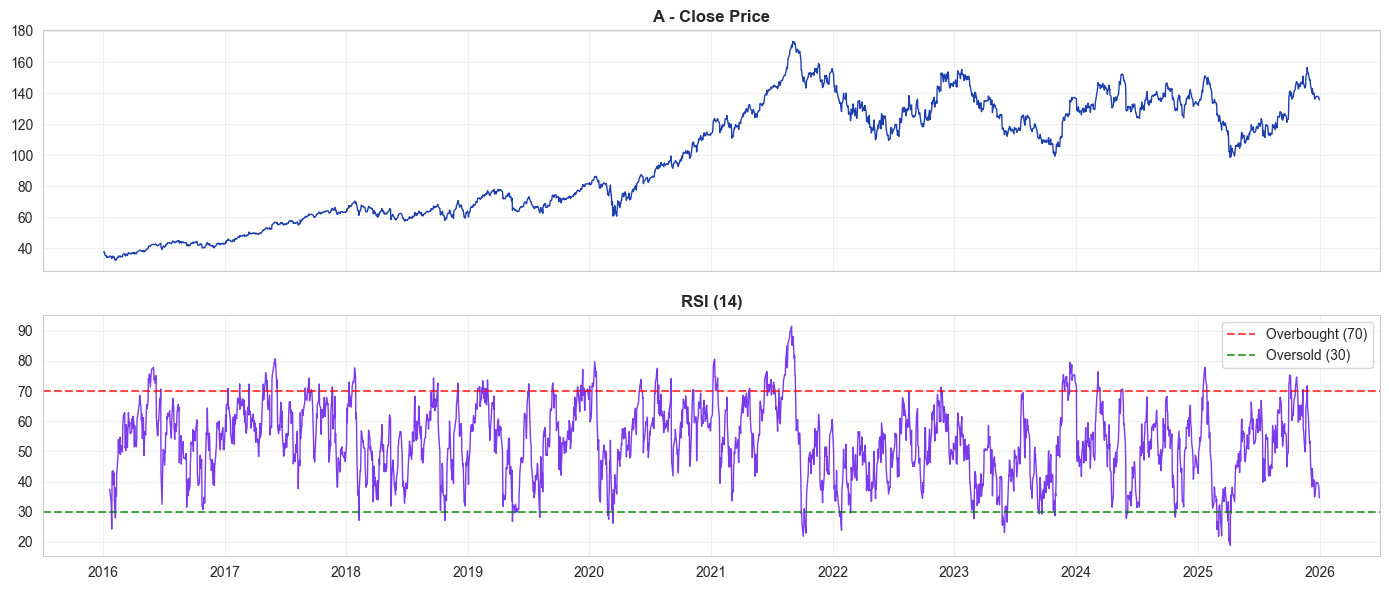

In [19]:
# RSI
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(s["date"], s["close"], color="#1e40af", linewidth=1)
axes[0].set_title(f"{SAMPLE_TICKER} - Close Price", fontweight="bold")
axes[0].grid(True, alpha=0.3)

axes[1].plot(s["date"], s["RSI_14"], color="#7c3aed", linewidth=1)
axes[1].axhline(70, color="red",   linestyle="--", alpha=0.7, label="Overbought (70)")
axes[1].axhline(30, color="green", linestyle="--", alpha=0.7, label="Oversold (30)")
axes[1].set_title("RSI (14)", fontweight="bold")
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

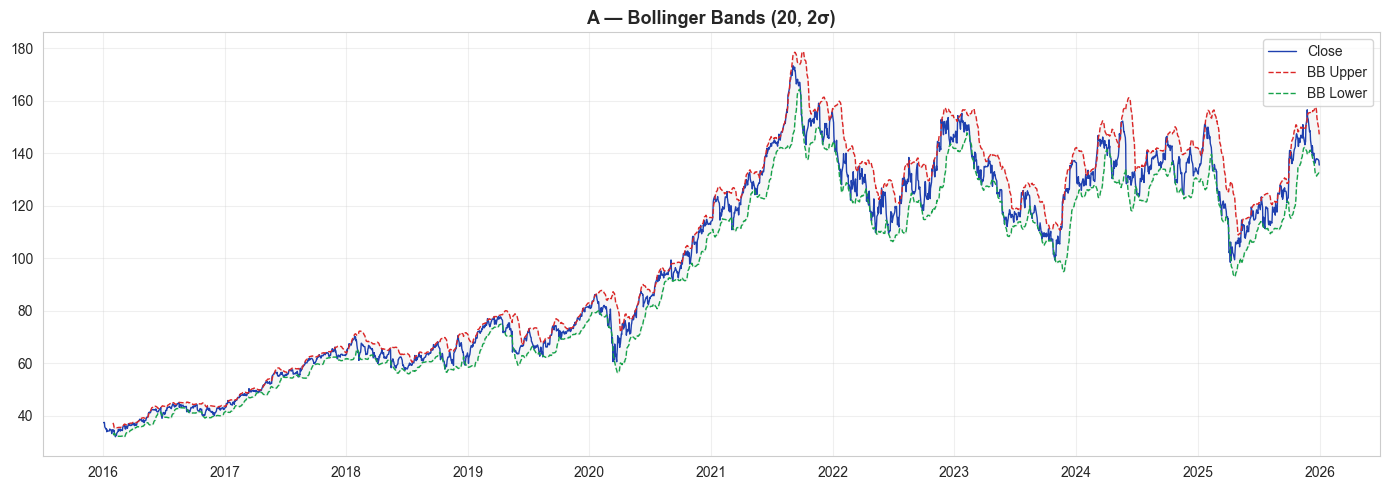

In [ ]:
# Bollinger Bands
plt.figure(figsize=(14, 5))
plt.plot(s["date"], s["close"],    label="Close",    color="#1e40af", linewidth=1)
plt.plot(s["date"], s["BB_Upper"], label="BB Upper", color="#dc2626", linewidth=1, linestyle="--")
plt.plot(s["date"], s["BB_Lower"], label="BB Lower", color="#16a34a", linewidth=1, linestyle="--")
plt.fill_between(s["date"], s["BB_Lower"], s["BB_Upper"], alpha=0.07, color="gray")
plt.title(f"{SAMPLE_TICKER} - Bollinger Bands (20, 2σ)", fontsize=13, fontweight="bold")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

In [21]:
print(f"Volume spikes detected across all stocks: {df['Volume_Spike'].sum():,}")

Volume spikes detected across all stocks: 39,344


## Step:2 Descriptive Statistics

In [ ]:
# Overall descriptive statistics for numeric columns
desc = df[['open', 'high', 'low', 'close', 'volume']].describe().T
desc['median'] = df[['open', 'high', 'low', 'close', 'volume']].median()
desc['skewness'] = df[['open', 'high', 'low', 'close', 'volume']].skew()
desc['kurtosis'] = df[['open', 'high', 'low', 'close', 'volume']].kurtosis()
print(desc.round(4))

In [ ]:
# Per symbol Stats: avg closing price and volume, volatility (std of close), and trading frequency
symbol_stats = df.groupby('symbol').agg(
    avg_close=('close', 'mean'),
    std_close=('close', 'std'),
    avg_volume=('volume', 'mean'),
    trading_days=('date', 'count')
).sort_values('avg_close', ascending=False)

print("Top 10 highest avg price stocks:\n", symbol_stats.head(10))
print("\nTop 10 most traded stocks:\n", symbol_stats.sort_values('avg_volume', ascending=False).head(10))

## Step:3 Missing Values Analysis


In [ ]:
# Check for missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(4)
})
print(missing_df)

# Plot only columns that actually have missing values
fig, ax = plt.subplots()
missing_to_plot = missing_pct[missing_pct > 0]

if len(missing_to_plot) > 0:
    missing_to_plot.plot(kind='bar', ax=ax, color='salmon')
    ax.set_title('Missing Value Percentage by Column')
    ax.set_ylabel('% Missing')
    ax.set_xlabel('Column')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")

# Checking for stocks with incomplete date coverage
expected_days = df['date'].nunique()
stock_coverage = df.groupby('symbol')['date'].count()
incomplete_stocks = stock_coverage[stock_coverage < expected_days * 0.9]

print(f"\nStocks with <90% date coverage: {len(incomplete_stocks)}")
print(incomplete_stocks.sort_values().head(10))

## Step:4 Outlier Detection

In [ ]:
# IQR method to count outliers in each numeric column
def count_outliers_iqr(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return ((series < Q1 - 1.5*IQR) | (series > Q3 + 1.5*IQR)).sum()

for col in ['open', 'high', 'low', 'close', 'volume']:
    n = count_outliers_iqr(df[col])
    print(f"{col}: {n} outliers ({n/len(df)*100:.2f}%)")

In [ ]:
# Box plots for OHLCV columns to visualize outliers
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for ax, col in zip(axes, ['open', 'high', 'low', 'close', 'volume']):
    df[col].plot(kind='box', ax=ax, color='steelblue')
    ax.set_title(col.capitalize())
    ax.set_xlabel('')
plt.suptitle('Box Plots — OHLCV Columns (Outlier Overview)', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Data integrity check: high >= low, high >= close, etc.
invalid_hl = (df['high'] < df['low']).sum()
invalid_hc = (df['high'] < df['close']).sum()
invalid_lo = (df['low'] > df['open']).sum()
print(f"Rows where high < low: {invalid_hl}")
print(f"Rows where high < close: {invalid_hc}")
print(f"Rows where low > open: {invalid_lo}")

## Step:5 Distribution Analysis

In [ ]:
# Histograms for OHLCV columns to visualize distributions
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(['open', 'high', 'low', 'close', 'volume']):
    axes[i].hist(df[col].dropna(), bins=60, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Distribution of {col.capitalize()}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
axes[-1].set_visible(False)
plt.suptitle('OHLCV Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

## Step:6 Correlation & Relationship Analysis

In [ ]:
# Correlation heatmap for OHLCV features
corr = df[['open', 'high', 'low', 'close', 'volume']].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('OHLCV Feature Correlation Heatmap')
plt.tight_layout()
plt.show()
print("\nInterpretation: Open/High/Low/Close are strongly correlated (multicollinearity risk).")
print("Volume has weaker correlation - may be a useful independent signal.")

In [ ]:
# Daily return distribution and Q-Q plot
df = df.sort_values(['symbol', 'date'])
df['daily_return'] = df.groupby('symbol')['close'].pct_change()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df['daily_return'].dropna().clip(-0.5, 0.5).plot(
    kind='hist', bins=100, ax=axes[0], color='steelblue')
axes[0].set_title('Daily Return Distribution')
axes[0].set_xlabel('Daily Return')

stats.probplot(df['daily_return'].dropna().clip(-0.5, 0.5), plot=axes[1])
axes[1].set_title('Q-Q Plot of Daily Returns')
plt.tight_layout()
plt.show()

print("Skewness:", round(df['daily_return'].skew(), 4))
print("Kurtosis:", round(df['daily_return'].kurtosis(), 4))

In [ ]:
# Scatter plot of volume vs daily return (using a sample for clarity)
sample = df[['volume', 'daily_return']].dropna().sample(5000, random_state=42)
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(np.log1p(sample['volume']), sample['daily_return'].clip(-0.3, 0.3),
           alpha=0.2, s=10, color='steelblue')
ax.set_xlabel('Log Volume')
ax.set_ylabel('Daily Return')
ax.set_title('Volume vs Daily Return (Sample of 5000)')
plt.tight_layout()
plt.show()

## Step:7 Time Series Trend Analysis

In [ ]:
# Market-wide average closing price over time
daily_avg = df.groupby('date')['close'].mean()
fig, ax = plt.subplots(figsize=(14, 5))
daily_avg.plot(ax=ax, color='steelblue', linewidth=1)
ax.set_title('Market-Wide Average Closing Price (2016–2025)')
ax.set_xlabel('Date')
ax.set_ylabel('Avg Close Price')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

In [ ]:
# Average daily volume over time
daily_vol = df.groupby('date')['volume'].mean()
fig, ax = plt.subplots(figsize=(14, 5))
daily_vol.plot(ax=ax, color='coral', linewidth=1)
ax.set_title('Market-Wide Average Daily Volume (2016–2025)')
ax.set_xlabel('Date')
ax.set_ylabel('Avg Volume')
plt.tight_layout()
plt.show()

In [ ]:
# Price trend for top 5 stocks by avg volume
top5 = symbol_stats.sort_values('avg_volume', ascending=False).head(5).index.tolist()
fig, ax = plt.subplots(figsize=(14, 6))
for sym in top5:
    subset = df[df['symbol'] == sym].set_index('date')['close']
    subset.plot(ax=ax, label=sym, linewidth=1.2)
ax.set_title('Closing Price — Top 5 Most Traded Stocks')
ax.set_xlabel('Date')
ax.set_ylabel('Close Price')
ax.legend()
plt.tight_layout()
plt.show()

## Step:8 Market Volatility Analysis

In [ ]:
# Rolling volatility of the market (using daily returns)
market_returns = df.groupby('date')['daily_return'].mean()
rolling_vol = market_returns.rolling(30).std() * np.sqrt(252)  # annualized

fig, ax = plt.subplots(figsize=(14, 5))
rolling_vol.plot(ax=ax, color='crimson', linewidth=1)
ax.set_title('Market Annualized Rolling Volatility (30-day window)')
ax.set_xlabel('Date')
ax.set_ylabel('Annualized Volatility')
plt.tight_layout()
plt.show()
# This should clearly show 2020 COVID spike and other market events

## Step:9 Class Distribution/Target Variable analysis

In [ ]:
# Define the target variable: 1 if next day's close is higher than today's, else 0
df['target'] = (df.groupby('symbol')['close'].shift(-1) > df['close']).astype(float)

class_dist = df['target'].value_counts(normalize=True)
print("Class distribution:\n", class_dist.round(4))

fig, ax = plt.subplots(figsize=(6, 4))
class_dist.plot(kind='bar', ax=ax, color=['coral', 'steelblue'])
ax.set_title('Target Class Distribution (0=Down, 1=Up)')
ax.set_xticklabels(['Down (0)', 'Up (1)'], rotation=0)
ax.set_ylabel('Proportion')
plt.tight_layout()
plt.show()

## Step:10 Data Quality Summary

In [ ]:
# Summary Table

print("DATA QUALITY SUMMARY")
print("")
print(f"Total records:          {len(df):,}")
print(f"Unique stocks:          {df['symbol'].nunique()}")
print(f"Date range:             {df['date'].min().date()} -> {df['date'].max().date()}")
print(f"Missing values (any):   {df.isnull().any(axis=1).sum():,}")
print(f"Duplicate rows:         {df.duplicated().sum():,}")
print(f"Invalid OHLC rows:      {(df['high'] < df['low']).sum():,}")
print(f"Stocks w/ <90% cover:   {len(incomplete_stocks)}")